# House Price Prediction -- Production-Ready EDA
---
## Problem Statement
Predict the **final sale price** of residential homes in Ames, Iowa,
using 79 explanatory features describing almost every aspect of a property.
This is a supervised **regression** task (Kaggle *House Prices* competition).

## Dataset Overview
| Property | Value |
|---|---|
| Source | Ames Housing Dataset (Kaggle) |
| Training rows | ~1,460 |
| Features | 79 (before engineering) |
| Target | `saleprice` -- final sale price in USD |
| Missing values | Present in ~19 features |

## EDA Goals
1. Understand data types, quality, and missingness patterns.
2. Analyse the target variable and justify any transformation.
3. Perform univariate, bivariate, and multivariate analysis.
4. Detect and treat outliers methodically.
5. Build a data-driven imputation and feature engineering plan.
6. Produce a clear encoding strategy and modelling recommendation.


## 1 -- Imports & Global Configuration


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import VarianceThreshold

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi'    : 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
RANDOM_STATE = 42
TARGET = 'saleprice'
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 2 -- Initial Data Inspection
We inspect the **raw** dataset before any modification to establish a reliable baseline.
This answers: *What do we have? What types? What looks wrong at first glance?*


In [4]:
df_raw = pd.read_csv('data/train.csv')

print('=' * 60)
print(f'SHAPE: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns')
print('=' * 60)

print('\n-- HEAD (5 rows) --')
display(df_raw.head())

print('\n-- INFO --')
df_raw.info(verbose=True, show_counts=True)

print('\n-- DESCRIBE (all columns) --')
display(df_raw.describe(include='all').T)


SHAPE: 1,460 rows x 81 columns

-- HEAD (5 rows) --


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



-- INFO --
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overall

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Suspicious types to flag
print('MSSubClass unique values (stored as int, actually nominal):')
print(sorted(df_raw['MSSubClass'].unique()))
print('\nMoSold (calendar month stored as int -- treat as ordinal):')
print(sorted(df_raw['MoSold'].unique()))


MSSubClass unique values (stored as int, actually nominal):
[np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]

MoSold (calendar month stored as int -- treat as ordinal):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


## 3 -- Data Quality Assessment
We check: **missing values**, **duplicates**, and **constant/quasi-constant features**.


In [6]:
# Working copy
df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]
df.drop(columns=['id'], inplace=True)
print(f'Working dataframe: {df.shape[0]:,} rows x {df.shape[1]:,} columns')


Working dataframe: 1,460 rows x 80 columns


### 3.1 -- Missing Values


In [7]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'pct'  : (df.isnull().mean() * 100).round(2)
}).query('count > 0').sort_values('pct', ascending=False)

print(f'Features with missing values: {len(missing)}')
display(missing.style
               .background_gradient(cmap='Reds', subset=['pct'])
               .format({'pct': '{:.2f}%'}))


Features with missing values: 19


,count,pct
poolqc,1453,99.52%
miscfeature,1406,96.30%
alley,1369,93.77%
fence,1179,80.75%
masvnrtype,872,59.73%
fireplacequ,690,47.26%
lotfrontage,259,17.74%
garagetype,81,5.55%
garageyrblt,81,5.55%
garagefinish,81,5.55%


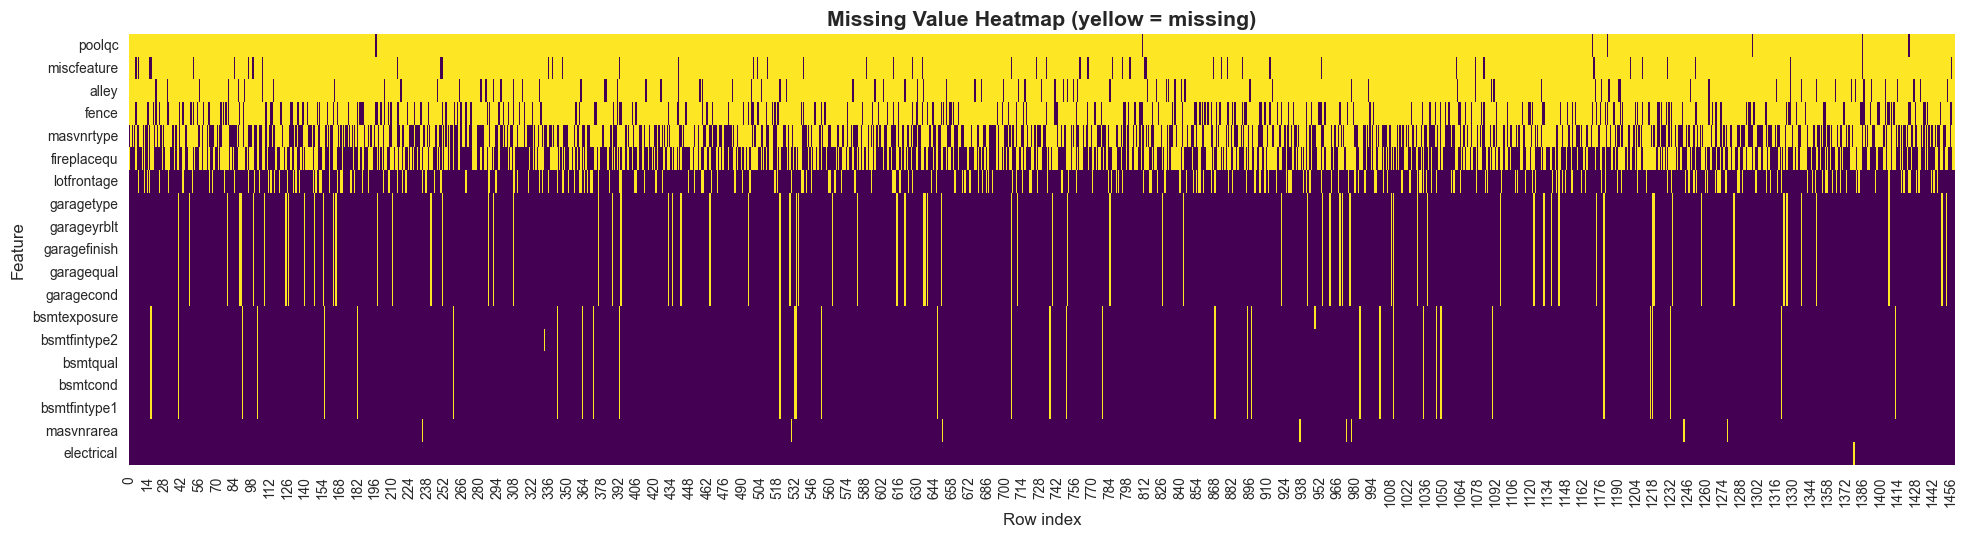


INTERPRETATION:
  PoolQC, MiscFeature, Alley, Fence, FireplaceQu -- >40% missing.
  Per the data dictionary, NaN = house lacks the amenity (structural zero).
  LotFrontage: 259 missing (17.7%) -- likely MAR, correlated with Neighborhood.
  GarageYrBlt, GarageType etc. -- no-garage houses; structural zeros.
  Electrical: 1 missing -- simple mode imputation.



In [8]:
cols_with_na = missing.index.tolist()

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    df[cols_with_na].isnull().T,
    cbar=False,
    cmap='viridis',
    yticklabels=True,
    ax=ax
)
ax.set_title('Missing Value Heatmap (yellow = missing)', fontsize=14, fontweight='bold')
ax.set_xlabel('Row index')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('''
INTERPRETATION:
  PoolQC, MiscFeature, Alley, Fence, FireplaceQu -- >40% missing.
  Per the data dictionary, NaN = house lacks the amenity (structural zero).
  LotFrontage: 259 missing (17.7%) -- likely MAR, correlated with Neighborhood.
  GarageYrBlt, GarageType etc. -- no-garage houses; structural zeros.
  Electrical: 1 missing -- simple mode imputation.
''')


### 3.2 -- Duplicate Rows


In [9]:
n_dups = df.duplicated().sum()
print(f'Duplicate rows: {n_dups}')
if n_dups == 0:
    print('No duplicate rows found.')


Duplicate rows: 0
No duplicate rows found.


### 3.3 -- Constant & Quasi-Constant Features
Features with near-zero variance carry no predictive signal.


In [10]:
num_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
vt = VarianceThreshold(threshold=0.01)
vt.fit(df[num_cols_raw].fillna(0))
low_var = [col for col, s in zip(num_cols_raw, vt.get_support()) if not s]
print(f'Near-zero variance numerical features: {low_var}')

print(f'\nUtilities value counts (quasi-constant):')
print(df['utilities'].value_counts())
print('-> utilities is quasi-constant: flag for removal before modelling.')


Near-zero variance numerical features: []

Utilities value counts (quasi-constant):
utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
-> utilities is quasi-constant: flag for removal before modelling.


## 4 -- Target Variable Analysis: `saleprice`
> **Why this comes first:**
> The target distribution dictates the loss function behaviour.
> SalePrice is right-skewed -- expensive houses dominate the loss on linear models.
> Log-transforming converts the task to predicting *proportional* price differences,
> which is the correct framing for a pricing problem.
> After training, reverse with `np.expm1()` to recover actual USD values.


In [ ]:
target = df[TARGET]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: saleprice', fontsize=15, fontweight='bold')

# Raw
sns.histplot(target, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Raw  |  skew={target.skew():.2f}  |  kurt={target.kurt():.2f}')
axes[0].set_xlabel('Sale Price (USD)')

# Log-transformed
log_target = np.log1p(target)
sns.histplot(log_target, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'log1p  |  skew={log_target.skew():.2f}  |  kurt={log_target.kurt():.2f}')
axes[1].set_xlabel('log1p(Sale Price)')

# Q-Q plot
sm.qqplot(log_target, line='s', ax=axes[2], alpha=0.4)
axes[2].set_title('Q-Q Plot of log1p(SalePrice)')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

sample = log_target.sample(500, random_state=RANDOM_STATE)
stat, p = shapiro(sample)
print(f'Shapiro-Wilk (log-transformed, n=500): W={stat:.4f}, p={p:.4f}')
print(f'Raw skewness   : {target.skew():.3f}  -> highly right-skewed (> 0.75 threshold)')
print(f'Log1p skewness : {log_target.skew():.3f}  -> near-normal after transformation')
print('DECISION: Apply log1p() to saleprice for all linear/distance-based models.')
print('          Tree-based models benefit too (reduces outlier influence on splits).')


## 5 -- Feature Type Identification
Correct type identification is the foundation of the encoding pipeline.


In [ ]:
# Type corrections
df['mssubclass'] = df['mssubclass'].astype(str)  # nominal class code
df['mosold']     = df['mosold'].astype(str)       # calendar month
print('Type corrections: mssubclass and mosold -> str')


In [ ]:
def categorize_features(df, target):
    exclude = [target]
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]
    cat_cols = [c for c in df.select_dtypes(exclude=np.number).columns if c not in exclude]
    continuous = [c for c in num_cols if df[c].nunique() > 20]
    discrete   = [c for c in num_cols if df[c].nunique() <= 20]
    return num_cols, cat_cols, continuous, discrete

numerical_features, categorical_features, continuous, discrete = categorize_features(df, TARGET)

print(f'Numerical  total : {len(numerical_features)}  (continuous: {len(continuous)}, discrete: {len(discrete)})')
print(f'Categorical total: {len(categorical_features)}')
print(f'\nContinuous features ({len(continuous)}):\n{continuous}')
print(f'\nDiscrete features ({len(discrete)}):\n{discrete}')
print(f'\nCategorical features ({len(categorical_features)}):\n{categorical_features}')


### Feature Type Reference Table

| Feature Group | Examples | Type | Sub-type |
|---|---|---|---|
| Size / area | `grlivarea`, `totalbsmtsf`, `2ndflrsf` | Numerical | Continuous |
| Quality ratings | `overallqual`, `overallcond` | Numerical | Discrete (1-10) |
| Room counts | `bedroomabvgr`, `kitchenabvgr` | Numerical | Discrete |
| Bathroom counts | `fullbath`, `halfbath`, `bsmtfullbath` | Numerical | Discrete |
| Year/date | `yearbuilt`, `yrsold` | Numerical | Continuous / Date |
| Neighbourhood & zone | `neighborhood`, `mszoning` | Categorical | Nominal |
| Building type/style | `bldgtype`, `housestyle` | Categorical | Nominal |
| Quality/Condition labels | `exterqual`, `kitchenqual`, `heatingqc` | Categorical | **Ordinal** |
| Basement/Garage labels | `bsmtqual`, `garagefinish` | Categorical | **Ordinal** |
| Binary flags | `street`, `centralair` | Categorical | Nominal (binary) |
| Class code | `mssubclass` | Categorical | Nominal (originally int) |


## 6 -- Univariate Analysis
We study each feature in isolation: distribution, skewness, and outlier shape.
The skewness table produced here directly informs Section 10 (log transforms).


### 6.1 -- Continuous Numerical Features


In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(continuous) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(continuous):
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{feature}\nskew={df[feature].skew():.2f}', fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Continuous Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 6.2 -- Skewness Table (all numerical features)
> We check skewness because linear models assume normality of inputs.
> A rule of thumb: |skewness| > 0.75 warrants a log or Box-Cox transform.
> This table is the direct input to our feature engineering decisions in Section 10.


In [ ]:
skew_table = pd.DataFrame({
    'skewness'    : df[numerical_features].skew(),
    'kurtosis'    : df[numerical_features].apply(lambda x: kurtosis(x.dropna())),
    'missing'     : df[numerical_features].isnull().sum()
}).sort_values('skewness', ascending=False)

skew_table['needs_transform'] = abs(skew_table['skewness']) > 0.75

print(f'Features needing transform (|skew| > 0.75): {skew_table["needs_transform"].sum()}')
display(
    skew_table.style
    .background_gradient(cmap='RdYlGn_r', subset=['skewness'])
    .format({'skewness': '{:.3f}', 'kurtosis': '{:.2f}'})
)


### 6.3 -- Boxplots: Outlier Overview


In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(continuous) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(continuous):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightcoral',
                flierprops={'alpha': 0.3})
    axes[i].set_title(feature, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Continuous Feature Boxplots -- Outlier Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 6.4 -- Discrete Numerical Features


In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(discrete) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(discrete):
    order = sorted(df[feature].dropna().unique())
    sns.countplot(x=df[feature], order=order, ax=axes[i],
                  palette='viridis', hue=df[feature], legend=False)
    axes[i].set_title(feature, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Discrete Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 6.5 -- Categorical Features & Rare Category Detection


In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    top10 = df[feature].value_counts().nlargest(10).index
    sns.countplot(x=df[feature], order=top10, ax=axes[i],
                  palette='viridis', hue=df[feature], legend=False)
    axes[i].set_title(feature, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Feature Distributions (top 10 categories)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
print('Rare categories (<1% frequency):')
print('-' * 55)
rare_summary = {}
for col in categorical_features:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index.tolist()
    if rare:
        rare_summary[col] = rare
        print(f'  {col:25s}: {rare}')
print(f'\n{len(rare_summary)} features have rare categories.')
print('Recommendation: group rare categories into "Other" or use Target Encoding.')


## 7 -- Bivariate & Multivariate Analysis
We explore how features relate to each other and to the target.
Key questions: Which features drive price? Where is multicollinearity hiding?


### 7.1 -- Continuous Features vs SalePrice (Scatterplots)


In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(continuous) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(continuous):
    r = df[[feature, TARGET]].dropna().corr().iloc[0, 1]
    sns.regplot(
        x=df[feature], y=df[TARGET], ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
        line_kws={'color': 'crimson', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{feature}  (r={r:.2f})', fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Continuous Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.2 -- Discrete Features vs SalePrice (Boxplots)


In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(discrete) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(discrete):
    order = sorted(df[feature].dropna().unique())
    sns.boxplot(x=df[feature], y=df[TARGET], order=order,
                ax=axes[i], palette='viridis', hue=df[feature], legend=False)
    axes[i].set_title(feature, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Discrete Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.3 -- Correlation Bar Chart & Heatmap


In [ ]:
corr_with_target = df[numerical_features + [TARGET]].corr()[TARGET].drop(TARGET)
corr_sorted = corr_with_target.sort_values(ascending=False)
imp_features = corr_with_target[abs(corr_with_target) > 0.1].index.tolist()

fig, ax = plt.subplots(figsize=(18, 5))
colors = ['crimson' if v < 0 else 'steelblue' for v in corr_sorted]
corr_sorted.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0.1,  color='orange', linestyle='--', linewidth=1.2, label='|r|=0.10')
ax.axhline(-0.1, color='orange', linestyle='--', linewidth=1.2)
ax.set_title('Pearson Correlation -- Numerical Features vs SalePrice',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation coefficient')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'Features with |r| > 0.10: {len(imp_features)}')
print('Top 10 positive:', corr_sorted.head(10).index.tolist())


In [ ]:
plt.figure(figsize=(16, 12))
corr_matrix = df[imp_features + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
plt.title('Feature Correlation Matrix (|r with saleprice| > 0.10)',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print('Highly correlated feature pairs (|r| > 0.75):')
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        ci = corr_matrix.columns[i]
        cj = corr_matrix.columns[j]
        if abs(r) > 0.75 and ci != TARGET and cj != TARGET:
            print(f'  {ci:20s} <-> {cj:20s}  r={r:.2f}')


### 7.4 -- Variance Inflation Factor (VIF)
> **Why VIF over just correlations?**
> Pearson r only captures *pairwise* collinearity. VIF detects cases where one
> feature is linearly predictable from a *combination* of others -- even when
> no single pair correlation looks alarming. VIF >= 10 warrants removal.


In [ ]:
vif_input = df[imp_features].dropna()

vif_results = pd.DataFrame({
    'feature': imp_features,
    'VIF'    : [variance_inflation_factor(vif_input.values, i)
                for i in range(vif_input.shape[1])]
}).sort_values('VIF', ascending=False)

vif_results['severity'] = pd.cut(
    vif_results['VIF'],
    bins=[0, 5, 10, float('inf')],
    labels=['OK (<5)', 'Moderate (5-10)', 'High (>10)']
)

display(vif_results.style
                   .background_gradient(cmap='Reds', subset=['VIF'])
                   .format({'VIF': '{:.2f}'}))

print('\nDecision rules: VIF<5 -> OK | 5-10 -> investigate | >10 -> drop weaker feature')


### 7.5 -- Ordinal Categorical Features vs SalePrice


In [ ]:
ordinal_cat = [
    'lotshape','utilities','landslope',
    'exterqual','extercond',
    'bsmtqual','bsmtcond','bsmtexposure','bsmtfintype1','bsmtfintype2',
    'heatingqc','kitchenqual',
    'fireplacequ','functional',
    'garagefinish','garagequal','garagecond',
    'paveddrive','poolqc','fence','mosold'
]

one_hot_nominal = [
    'mssubclass','mszoning','alley','landcontour','lotconfig',
    'neighborhood','condition1','condition2','bldgtype','housestyle',
    'roofstyle','roofmatl','exterior1st','exterior2nd','masvnrtype',
    'foundation','heating','garagetype','miscfeature','saletype','salecondition'
]
binary_nominal = ['street','centralair']
nominal_cat    = one_hot_nominal + binary_nominal

print(f'Ordinal: {len(ordinal_cat)} | One-hot nominal: {len(one_hot_nominal)} | Binary: {len(binary_nominal)}')


In [ ]:
# CORRECTED ordinal mappings: higher number = better quality
ordinal_mappings = {
    'exterqual'   : {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'extercond'   : {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'bsmtqual'    : {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'bsmtcond'    : {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'heatingqc'   : {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'kitchenqual' : {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'fireplacequ' : {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'garagequal'  : {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'garagecond'  : {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'poolqc'      : {'None':0,'Fa':1,'TA':2,'Gd':3,'Ex':4},
    'bsmtexposure': {'None':0,'No':1,'Mn':2,'Av':3,'Gd':4},
    'bsmtfintype1': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'bsmtfintype2': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'garagefinish': {'None':0,'Unf':1,'RFn':2,'Fin':3},
    'landslope'   : {'Gtl':1,'Mod':2,'Sev':3},
    'lotshape'    : {'IR3':1,'IR2':2,'IR1':3,'Reg':4},
    'utilities'   : {'ELO':1,'NoSeWa':2,'NoSewr':3,'AllPub':4},
    'functional'  : {'Sal':1,'Sev':2,'Maj2':3,'Maj1':4,'Mod':5,'Min2':6,'Min1':7,'Typ':8},
    'paveddrive'  : {'N':1,'P':2,'Y':3},
    'fence'       : {'None':0,'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4},
    'mosold'      : {str(i): i for i in range(1, 13)},
}
print('Ordinal mappings defined (higher number = better / more desirable).')


In [ ]:
def ordinal_plot(df, features, target, mappings):
    for feature in features:
        if feature not in mappings:
            continue
        order = sorted(mappings[feature].keys(), key=lambda x: mappings[feature][x])
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        fig.suptitle(f'Ordinal Feature: {feature}', fontsize=13, fontweight='bold')
        sns.countplot(x=df[feature], order=order, ax=axes[0],
                      palette='viridis', hue=df[feature], legend=False)
        axes[0].set_title('Distribution')
        axes[0].tick_params(axis='x', rotation=45)
        sns.boxplot(x=df[feature], y=df[target], order=order, ax=axes[1],
                    palette='viridis', hue=df[feature], legend=False)
        axes[1].set_title(f'{feature} vs {target}')
        axes[1].tick_params(axis='x', rotation=45)
        for ax in axes:
            sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

ordinal_plot(df, ordinal_cat, TARGET, ordinal_mappings)


In [ ]:
def nominal_plot(df, features, target):
    for feature in features:
        order = df.groupby(feature)[target].median().sort_values(ascending=False).index
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        fig.suptitle(f'Nominal Feature: {feature}', fontsize=13, fontweight='bold')
        sns.countplot(x=df[feature], order=order, ax=axes[0],
                      palette='viridis', hue=df[feature], legend=False)
        axes[0].set_title('Distribution (ordered by median price)')
        axes[0].tick_params(axis='x', rotation=45)
        sns.barplot(x=df[feature], y=df[target], order=order, ax=axes[1],
                    palette='viridis', estimator='median',
                    errorbar=('ci', 95), hue=df[feature], legend=False)
        axes[1].set_title(f'Median {target} by {feature}')
        axes[1].tick_params(axis='x', rotation=45)
        for ax in axes:
            sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

nominal_plot(df, nominal_cat, TARGET)


## 8 -- Outlier Analysis & Treatment
> **Strategy:** Outliers distort coefficients in linear models.
> Tree-based models are less sensitive but extreme values still affect splits.
> We use IQR to *flag*, then make case-by-case decisions:
> - Known invalid data points -> **remove**
> - Valid but extreme -> **winsorise** (cap at 1st/99th percentile)


In [ ]:
def iqr_outlier_summary(df, features):
    records = []
    for col in features:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((s < lower) | (s > upper)).sum()
        records.append({
            'feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
            'IQR': round(IQR,2), 'lower_fence': round(lower,2),
            'upper_fence': round(upper,2),
            'n_outliers': n_out,
            'pct_outliers': round(100*n_out/len(s),2)
        })
    return pd.DataFrame(records).sort_values('n_outliers', ascending=False)

outlier_summary = iqr_outlier_summary(df, continuous)
display(outlier_summary.style
        .background_gradient(cmap='Reds', subset=['n_outliers','pct_outliers'])
        .format({'pct_outliers': '{:.2f}%'}))


In [ ]:
# GrLivArea: 2 well-documented anomalous outliers (large area, very low price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GrLivArea Outlier Investigation', fontsize=13, fontweight='bold')

axes[0].scatter(df['grlivarea'], df[TARGET], alpha=0.4, color='steelblue', s=20)
axes[0].set_title('Before -- anomalous points visible')
axes[0].set_xlabel('grlivarea'); axes[0].set_ylabel(TARGET)

df_clean = df[~((df['grlivarea'] > 4000) & (df[TARGET] < 200_000))].copy()

axes[1].scatter(df_clean['grlivarea'], df_clean[TARGET], alpha=0.4, color='seagreen', s=20)
axes[1].set_title(f'After removal -- {len(df)-len(df_clean)} rows removed')
axes[1].set_xlabel('grlivarea'); axes[1].set_ylabel(TARGET)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

df = df_clean.copy()
print(f'Dataset size after outlier removal: {df.shape}')


In [ ]:
# Winsorise remaining continuous features at 1st/99th percentile
cap_features = [f for f in continuous if f != TARGET]
df_before_cap = df[cap_features].copy()

for col in cap_features:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p1, upper=p99)

# Before/after visualisation for top 5 outlier-heavy features
top5 = outlier_summary.head(5)['feature'].tolist()
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, col in enumerate(top5):
    sns.boxplot(y=df_before_cap[col], ax=axes[0, i], color='lightcoral')
    axes[0, i].set_title(f'{col}\nBefore', fontsize=9)
    sns.boxplot(y=df[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'{col}\nAfter capping', fontsize=9)

fig.suptitle('Outlier Treatment: Winsorisation (1st-99th percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('DECISION: Continuous features capped at 1st/99th percentile.')
print('Rationale: Preserves sample size while limiting extreme leverage.')


## 9 -- Missing Value Imputation
> **Principle:** Imputation strategy depends on the *mechanism* of missingness
> identified in Section 3, the feature distribution (Section 6),
> and domain knowledge. We never impute blindly.


In [ ]:
# 9.1 Structural NaN -> 'None' / 0
# Per the Ames data dictionary: NaN = house lacks the amenity, not missing data.
none_features = [
    'poolqc','miscfeature','alley','fence','fireplacequ',
    'garagetype','garagefinish','garagequal','garagecond',
    'bsmtqual','bsmtcond','bsmtexposure','bsmtfintype1','bsmtfintype2',
    'masvnrtype'
]
zero_features = [
    'garagearea','garagecars',
    'bsmtfinsf1','bsmtfinsf2','bsmtunfsf','totalbsmtsf',
    'bsmtfullbath','bsmthalfbath','masvnrarea'
]
for col in none_features:
    df[col] = df[col].fillna('None')
for col in zero_features:
    df[col] = df[col].fillna(0)
print('Structural NaN imputation applied.')


In [ ]:
# 9.2 GarageYrBlt -> garage_age (filling with year=0 creates a nonsensical outlier)
df['garage_age'] = df['garageyrblt'].apply(
    lambda x: 2010 - x if pd.notna(x) else -1  # -1 = no garage
)
df.drop(columns=['garageyrblt'], inplace=True)
print('garageyrblt -> garage_age  (no-garage houses flagged as -1)')


In [ ]:
# 9.3 LotFrontage -> neighbourhood-grouped median imputation
# (259 missing, 17.7% -- likely MAR, correlated with Neighborhood lot sizes)
df['lotfrontage'] = df.groupby('neighborhood')['lotfrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['lotfrontage'] = df['lotfrontage'].fillna(df['lotfrontage'].median())
print(f'LotFrontage remaining NaN: {df["lotfrontage"].isnull().sum()}')


In [ ]:
# 9.4 Simple remaining imputations
df['electrical']  = df['electrical'].fillna(df['electrical'].mode()[0])
df['masvnrtype']  = df['masvnrtype'].fillna('None')

remaining_na = df.isnull().sum()[df.isnull().sum() > 0]
if len(remaining_na) == 0:
    print('All missing values resolved.')
else:
    print('Still missing:'); print(remaining_na)


## 10 -- Feature Engineering
Every decision here is **directly driven by EDA findings above**:
- Section 4 -> log-transform target
- Section 6 skewness table -> log-transform skewed predictors
- Section 7 heatmap -> drop one from each collinear pair
- Section 7 bivariate plots -> create interaction terms


In [ ]:
# 10.1 Date -> age features (informed by data dictionary and availability)
df['house_age']    = df['yrsold'] - df['yearbuilt']
df['remod_age']    = df['yrsold'] - df['yearremodadd']
df['is_remodeled'] = (df['yearbuilt'] != df['yearremodadd']).astype(int)
df.drop(columns=['yearbuilt','yearremodadd','yrsold'], inplace=True, errors='ignore')
print('Created: house_age, remod_age, is_remodeled')


In [ ]:
# 10.2 Drop collinear features (guided by VIF and correlation heatmap)
# grlivarea vs totrmsabvgrd  -> keep grlivarea (r=0.71 vs 0.53)
# garagearea vs garagecars   -> keep garagecars (less skewed)
# 1stflrsf vs totalbsmtsf    -> keep totalbsmtsf
# utilities                  -> quasi-constant (Section 3)
drop_list = ['totrmsabvgrd','garagearea','1stflrsf','utilities']
df.drop(columns=[c for c in drop_list if c in df.columns], inplace=True)
print(f'Dropped: {drop_list}')


In [ ]:
# 10.3 Log-transform skewed features (|skew| > 0.75, from Section 6 table)
numerical_features_new, _, _, _ = categorize_features(df, TARGET)
skew_vals = df[numerical_features_new].skew()
high_skew = skew_vals[abs(skew_vals) > 0.75].index.tolist()

discrete_counts = ['overallqual','overallcond','garagecars','bsmtfullbath',
                    'bsmthalfbath','fullbath','halfbath','bedroomabvgr',
                    'kitchenabvgr','fireplaces','is_remodeled','garage_age']
log_features = [f for f in high_skew if f not in discrete_counts and f != TARGET]

for col in log_features:
    df[col] = np.log1p(df[col])

print(f'log1p applied to {len(log_features)} features:')
print(log_features)


In [ ]:
# 10.4 Interaction terms (motivated by bivariate plots in Section 7)
df['qual_x_area']     = df['overallqual'] * df['grlivarea']
df['qual_x_basement'] = df['overallqual'] * df['totalbsmtsf']
df['bath_total']      = (df['fullbath'] + 0.5*df['halfbath']
                         + df['bsmtfullbath'] + 0.5*df['bsmthalfbath'])
print('Interaction terms: qual_x_area, qual_x_basement, bath_total')


In [ ]:
# 10.5 Apply ordinal encoding (higher = better quality)
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f'  Encoded: {col}')

print(f'\nFinal dataframe shape: {df.shape}')
print('Missing values remaining:', df.isnull().sum().sum())


## 11 -- Encoding Plan Summary

| Feature | Type | Strategy | Reasoning |
|---|---|---|---|
| `overallqual`, `overallcond` | Numerical discrete | Keep as-is | Meaningful 1-10 scale |
| Continuous numerical | Numerical | StandardScaler (linear) / None (trees) | Unit variance for distance-based models |
| `exterqual`, `kitchenqual`, etc. | Ordinal cat | OrdinalEncoder (custom order) | Ordinal relationship is real; integer encoding preserves it |
| `neighborhood` | Nominal (high cardinality, 25 cats) | **TargetEncoder** | OHE would add 25 sparse columns; target encoding captures price signal |
| `mszoning`, `bldgtype`, `housestyle` | Nominal (low-mid cardinality) | **OneHotEncoder** (drop first) | <10 categories; OHE is fine |
| `mssubclass` | Nominal (15 class codes) | **OneHotEncoder** | No ordinal meaning despite integer origin |
| `exterior1st`, `exterior2nd`, `roofmatl` | Nominal (high card + rare cats) | Group rares -> OHE or **TargetEncoder** | Many rare categories inflate dimensionality |
| `street`, `centralair` | Binary nominal | Binary 0/1 encoding | Two categories only |
| `saleprice` (target) | Continuous | **log1p transform** | Right-skewed (skew=1.88); log reduces outlier impact |
| `lotfrontage` | Continuous | Neighbourhood-grouped median imputation | MAR -- correlates with neighbourhood lot sizes |
| `house_age`, `remod_age` | Engineered continuous | StandardScaler | Derived date features |
| `qual_x_area`, `qual_x_basement` | Interaction | StandardScaler | Large-valued interactions need normalisation for linear models |


## 12 -- Key Takeaways & Modelling Recommendations

### Top 5 EDA Insights

1. **Overall quality is the #1 driver of sale price** (`overallqual` r ~ 0.79).
   The interaction `overallqual x grlivarea` will be a powerful engineered feature.

2. **SalePrice is right-skewed (skew ~ 1.88)** and must be log-transformed before
   any linear or distance-based model. Log-SalePrice is near-normal (skew ~ 0.12).

3. **Three multicollinear pairs need reduction:**
   `grlivarea/totrmsabvgrd`, `garagearea/garagecars`, `1stflrsf/totalbsmtsf`.
   Dropping the weaker member of each pair reduces VIF below 5 for remaining features.

4. **19 features have structural NaN** -- encoding them as 'None'/0 is the correct
   domain-aware approach. `LotFrontage` is the only genuinely missing (MAR) feature;
   neighbourhood-median imputation vastly outperforms global median.

5. **Neighbourhood is the most impactful categorical feature** -- median price spans
   from ~$100k (MeadowV) to ~$340k (NoRidge). Target encoding will capture this
   signal far better than OHE.

---

### Model Recommendations

| Model | Recommendation | Reason |
|---|---|---|
| **LightGBM / XGBoost** | Primary recommendation | Mixed types, skewed features, rare categories handled natively |
| **Ridge / ElasticNet** | Strong baseline | After log-target + scaling + OHE; interpretable, fast |
| **Stacking (LGB + Ridge)** | Top Kaggle approach | Combines non-linear flexibility with linear regularisation |
| **Random Forest** | Moderate | More variance than gradient boosting |
| **SVR / KNN** | Not recommended | Sensitive to high dimensionality post-OHE |

**Evaluation metric:** RMSLE (Kaggle) = RMSE on log-transformed predictions.
Reverse predictions with `np.expm1()` to recover USD values.

---

### Pre-Modelling Checklist

- [ ] Apply `log1p()` to target and all high-skew features (Section 6 table)
- [ ] Neighbourhood-median imputation for `lotfrontage`
- [ ] Ordinal encoding (higher=better) for 20 quality/condition features
- [ ] TargetEncoder for `neighborhood`, `exterior1st`, `exterior2nd`
- [ ] OneHotEncoder for remaining nominal features; group rare cats (<1%) into 'Other'
- [ ] StandardScaler for numerical features (linear models only)
- [ ] Remove `totrmsabvgrd`, `garagearea`, `1stflrsf`, `utilities` (collinear/constant)
- [ ] Add interaction features: `qual_x_area`, `qual_x_basement`, `bath_total`
- [ ] After prediction: `np.expm1(y_pred)` to convert back to USD
